<a href="https://colab.research.google.com/github/AndersStaxen/Class_Python_for_Policy/blob/main/Financial_Conditions_Indices_and_Equity_Returns.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Financial Conditions Indices and Equity Returns: A Brief Correlation Analysis**


---



### **Introduction**

This notebook explores the relationship between Financial Conditions Indices (FCIs) and the returns of the S&P 500 index.

FCIs are indicators that summarize the overall state of financial markets, encompassing factors like credit conditions, risk sentiment, and market volatility. FCIs usually assigns a single score between -1 and +1, with rising scores sugggesting more restrictive financial conditions, which can act as a drag on the economy. When FCIs fall, conditions are loosening, potentially providing a tailwind for economic activity.

Understanding the correlation between FCIs and equity returns can provide insights into how changes in financial conditions might influence stock market performance.


#### **Hypothesis**

Given the (very) brief introduction to FCIs, this research project hypothesizes that the direction of the FCI is more important than the relative score. The intutition behind this is that while the absolute level of the FCI provides a snapshot of the current state of the economy, equity markets are forward-looking and therefore performs in line with expectations rather than lagging indicators.

To investigate this hypothesis, this project aims to investigate whether the rate of change (derivatives) of the FCI has a stronger correlation with S&P 500 returns than the absolute level of the FCI.


#### **Data Collection**
The project uses two datasets:

1. Chicago Fed National Financial Conditions Index (NFCI.csv): This dataset contains the weekly values of the NFCI, which is the primary financial conditions index being analyzed.

2. S&P 500 Index (SP500.csv): This dataset contains the daily values of the S&P 500 index, which is used to calculate weekly equity returns.



---

### **Data Preparation**

The project begins by mounting Google Drive to access the necessary CSV files (NFCI.csv and SP500.csv). It then loads these files into pandas DataFrames.

Thereafter, the 'observation_date' columns in both DataFrames are converted to datetime objects and set as the index. The DataFrames are then filtered to the specified date range (2016-01-01 to 2024-12-31).

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd

nfci_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/FCIs and the S&P 500/NFCI.csv')
sp500_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/FCIs and the S&P 500/SP500.csv')

# Convert 'observation_date' to datetime and set as index
nfci_df['observation_date'] = pd.to_datetime(nfci_df['observation_date'])
sp500_df['observation_date'] = pd.to_datetime(sp500_df['observation_date'])

# Set 'observation_date' as index
nfci_df.set_index('observation_date', inplace=True)
sp500_df.set_index('observation_date', inplace=True)

# Filter dataframes to the specified date range
start_date = '2016-01-01'
end_date = '2024-12-31'
nfci_filtered_df = nfci_df.loc[start_date:end_date]
sp500_filtered_df = sp500_df.loc[start_date:end_date]

print("NFCI DataFrame (filtered):")
display(nfci_filtered_df.head())
print("\nSP500 DataFrame (filtered):")
display(sp500_filtered_df.head())

print("\nNFCI DataFrame Info:")
display(nfci_filtered_df.info())
print("\nSP500 DataFrame Info:")
display(sp500_filtered_df.info())

NFCI DataFrame (filtered):


,NFCI
observation_date,
2016-01-01,-0.34589
2016-01-08,-0.33020
2016-01-15,-0.31646
2016-01-22,-0.30614
2016-01-29,-0.29943



SP500 DataFrame (filtered):


,SP500
observation_date,
2016-01-01,NaN
2016-01-04,2012.66
2016-01-05,2016.71
2016-01-06,1990.26
2016-01-07,1943.09



NFCI DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 470 entries, 2016-01-01 to 2024-12-27
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   NFCI    470 non-null    float64
dtypes: float64(1)
memory usage: 7.3 KB


None


SP500 DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2348 entries, 2016-01-01 to 2024-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SP500   2264 non-null   float64
dtypes: float64(1)
memory usage: 36.7 KB


None

#### **Resampling and Merging**

Because the data for the S&P 500 is daily while the Chicago only publishes its data on fridays, there is an inconsistency between the two datasets. To solve this problem, the daily S&P 500 data is resampled to a weekly frequency (specifically, the Friday value) to match the NFCI data. The two DataFrames are then merged based on their date index.

In [4]:
# Resample S&P 500 to weekly frequency, taking the last value of the week
# sp500_weekly_df = sp500_filtered_df.resample('W').last()

# Resample S&P 500 to weekly frequency, taking the value from Friday
sp500_weekly_df = sp500_filtered_df.resample('W-FRI').last()


# Merge the two dataframes on their index (observation_date)
merged_df = pd.merge(nfci_filtered_df, sp500_weekly_df, left_index=True, right_index=True)

print("Merged DataFrame (weekly frequency):")
display(merged_df.head())
print("\nMerged DataFrame Info:")
display(merged_df.info())

Merged DataFrame (weekly frequency):


,NFCI,SP500
observation_date,,
2016-01-01,-0.34589,NaN
2016-01-08,-0.33020,1922.03
2016-01-15,-0.31646,1880.33
2016-01-22,-0.30614,1906.90
2016-01-29,-0.29943,1940.24



Merged DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 470 entries, 2016-01-01 to 2024-12-27
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   NFCI    470 non-null    float64
 1   SP500   469 non-null    float64
dtypes: float64(2)
memory usage: 11.0 KB


None

In [5]:
print("Weekly S&P 500 DataFrame (head and tail):")
display(sp500_weekly_df.head())
display(sp500_weekly_df.tail())

print("\nFiltered NFCI DataFrame (head and tail):")
display(nfci_filtered_df.head())
display(nfci_filtered_df.tail())

Weekly S&P 500 DataFrame (head and tail):


,SP500
observation_date,
2016-01-01,NaN
2016-01-08,1922.03
2016-01-15,1880.33
2016-01-22,1906.90
2016-01-29,1940.24


,SP500
observation_date,
2024-12-06,6090.27
2024-12-13,6051.09
2024-12-20,5930.85
2024-12-27,5970.84
2025-01-03,5881.63



Filtered NFCI DataFrame (head and tail):


,NFCI
observation_date,
2016-01-01,-0.34589
2016-01-08,-0.33020
2016-01-15,-0.31646
2016-01-22,-0.30614
2016-01-29,-0.29943


,NFCI
observation_date,
2024-11-29,-0.47858
2024-12-06,-0.48101
2024-12-13,-0.48271
2024-12-20,-0.48401
2024-12-27,-0.48831


#### **The S&P 500 in Percentage Returns**

As investors care less about the absolute value of the S&P 500 and more about the percentage returns, the weekly percentage change for the S&P 500 is calculated to represent weekly equity returns. A score of -2.169 for SP500_Returns means that the S&P 500 declined 2.169% that week.

In [16]:
# Calculate weekly percentage change for SP500
merged_df['SP500_Returns'] = merged_df['SP500'].pct_change() * 100

print("Merged DataFrame with SP500 Returns:")
display(merged_df.head())
display(merged_df.tail())

Merged DataFrame with SP500 Returns:


,NFCI,SP500,SP500_Returns,NFCI_Derivative,NFCI_Second_Derivative
observation_date,,,,,
2016-01-01,-0.34589,NaN,NaN,NaN,NaN
2016-01-08,-0.33020,1922.03,NaN,0.01569,NaN
2016-01-15,-0.31646,1880.33,-2.169581,0.01374,-0.00195
2016-01-22,-0.30614,1906.90,1.413050,0.01032,-0.00342
2016-01-29,-0.29943,1940.24,1.748387,0.00671,-0.00361


,NFCI,SP500,SP500_Returns,NFCI_Derivative,NFCI_Second_Derivative
observation_date,,,,,
2024-11-29,-0.47858,6032.38,1.056063,-0.00347,0.00158
2024-12-06,-0.48101,6090.27,0.959654,-0.00243,0.00104
2024-12-13,-0.48271,6051.09,-0.643321,-0.00170,0.00073
2024-12-20,-0.48401,5930.85,-1.987080,-0.00130,0.00040
2024-12-27,-0.48831,5970.84,0.674271,-0.00430,-0.00300


Now that the data preparation is done, the analysis can begin


---



## **Data Analysis**

The analysis begins with a simple scatter plot where each point shows us, for a given week, where the NFCI stood (on the horizontal axis) and how much the S&P 500 changed (on the vertical axis) as well as a trendline.

We expect this line to slope downwards, meaning that as financial conditions get tighter (NFCI goes up), stock returns would go down, and vice versa. However, as laid out in the beginning, we don't expect a strong relationship between the two as financial markets are forward-looking.

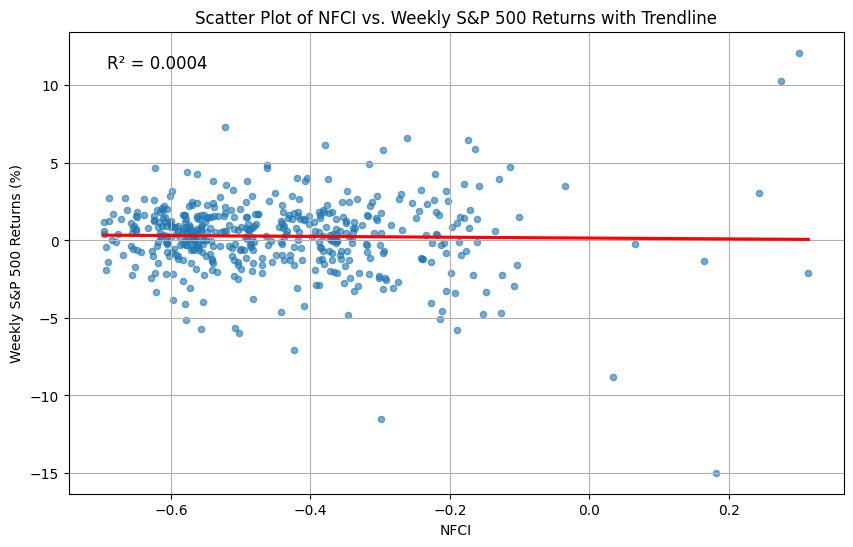

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

# Drop rows with missing values in SP500_Returns
merged_df_cleaned = merged_df.dropna(subset=['SP500_Returns'])

# Calculate the linear regression
slope, intercept, r_value, p_value, std_err = linregress(merged_df_cleaned['NFCI'], merged_df_cleaned['SP500_Returns'])
r_squared = r_value**2

plt.figure(figsize=(10, 6))
sns.regplot(data=merged_df_cleaned, x='NFCI', y='SP500_Returns', scatter_kws={'s': 20, 'alpha': 0.6}, line_kws={'color': 'red'}, ci=None)

plt.title('Scatter Plot of NFCI vs. Weekly S&P 500 Returns with Trendline')
plt.xlabel('NFCI')
plt.ylabel('Weekly S&P 500 Returns (%)')

# Add R-squared value to the plot
plt.text(0.05, 0.95, f'R² = {r_squared:.4f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')

plt.grid(True)
plt.show()

When looking at the plot, the trendline was almost flat. The points were scattered quite widely around this line, with a very low R-squared value (around 0.0004). This suggests that, over the period we studied, the absolute level of the NFCI on its own was a very weak predictor of how the S&P 500 would perform that week in a simple linear way.

Given that this initial look at the NFCI level didn't show a strong connection with S&P 500 returns, further analysis is required (as expected, in line with the general hypothesis that the derivatives have higher explanatory power). Thus, the project proceeds with calculating the first derivative of the NFCI and plotting it in a scatter plot.

In [8]:
# Calculate the first derivative of NFCI
merged_df['NFCI_Derivative'] = merged_df['NFCI'].diff()

print("Merged DataFrame with NFCI Derivative:")
display(merged_df.head())
display(merged_df.tail())

Merged DataFrame with NFCI Derivative:


,NFCI,SP500,SP500_Returns,NFCI_Derivative
observation_date,,,,
2016-01-01,-0.34589,NaN,NaN,NaN
2016-01-08,-0.33020,1922.03,NaN,0.01569
2016-01-15,-0.31646,1880.33,-2.169581,0.01374
2016-01-22,-0.30614,1906.90,1.413050,0.01032
2016-01-29,-0.29943,1940.24,1.748387,0.00671


,NFCI,SP500,SP500_Returns,NFCI_Derivative
observation_date,,,,
2024-11-29,-0.47858,6032.38,1.056063,-0.00347
2024-12-06,-0.48101,6090.27,0.959654,-0.00243
2024-12-13,-0.48271,6051.09,-0.643321,-0.00170
2024-12-20,-0.48401,5930.85,-1.987080,-0.00130
2024-12-27,-0.48831,5970.84,0.674271,-0.00430


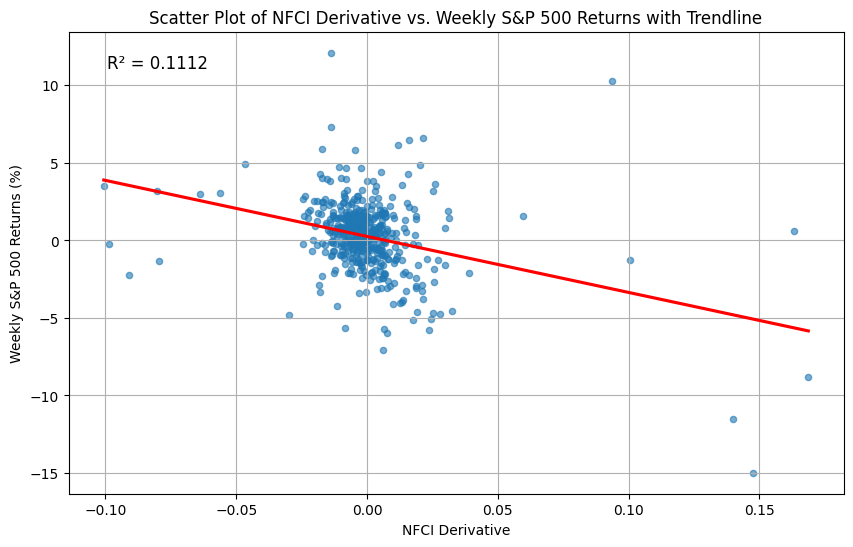

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

# Drop rows with missing values in SP500_Returns and NFCI_Derivative
merged_df_cleaned_derivative = merged_df.dropna(subset=['SP500_Returns', 'NFCI_Derivative'])

# Calculate the linear regression
slope_deriv, intercept_deriv, r_value_deriv, p_value_deriv, std_err_deriv = linregress(merged_df_cleaned_derivative['NFCI_Derivative'], merged_df_cleaned_derivative['SP500_Returns'])
r_squared_deriv = r_value_deriv**2

plt.figure(figsize=(10, 6))
sns.regplot(data=merged_df_cleaned_derivative, x='NFCI_Derivative', y='SP500_Returns', scatter_kws={'s': 20, 'alpha': 0.6}, line_kws={'color': 'red'}, ci=None)

plt.title('Scatter Plot of NFCI Derivative vs. Weekly S&P 500 Returns with Trendline')
plt.xlabel('NFCI Derivative')
plt.ylabel('Weekly S&P 500 Returns (%)')

# Add R-squared value to the plot
plt.text(0.05, 0.95, f'R² = {r_squared_deriv:.4f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')

plt.grid(True)
plt.show()

#### Interpretation of the Scatter Plot: NFCI Derivative vs. Weekly S&P 500 Returns

The scatter plot above shows the relationship between the week-over-week change in the NFCI (NFCI Derivative) and the weekly percentage returns of the S&P 500. Each point on the plot represents a specific week, with its position determined by the NFCI Derivative on the x-axis and the corresponding S&P 500 Return on the y-axis.

The trendline appears to be downward sloping, suggesting that when the NFCI Derivative is positive (financial conditions are tightening week-over-week), S&P 500 returns tend to be lower or negative. Conversely, when the NFCI Derivative is negative (financial conditions are loosening week-over-week), S&P 500 returns tend to be higher or positive. This aligns with the intuition that a tightening of financial conditions is generally unfavorable for equities, while a loosening is favorable.

However, the points are still quite scattered around the trendline, indicating that while there is a discernible trend, the relationship is not perfectly linear. Many other factors influence S&P 500 returns, and the NFCI Derivative is just one of them.

The R-squared value of approximately 0.1112 indicates that about 11.12% of the variance in weekly S&P 500 returns can be explained by the linear relationship with the NFCI Derivative. This is a significant improvement compared to the R-squared value of 0.0004 when using the NFCI level, suggesting that the change in financial conditions has a stronger linear association with short-term market returns than the absolute level of the index.

In summary, the scatter plot and trendline suggest a modest negative linear relationship between the NFCI Derivative and Weekly S&P 500 Returns. While the NFCI Derivative provides more explanatory power than the NFCI level in this analysis period, it still only accounts for a relatively small portion of the variation in S&P 500 returns.

The project proceeds with calculating and plotting the second derivative.

In [10]:
# Calculate the second derivative of NFCI
merged_df['NFCI_Second_Derivative'] = merged_df['NFCI_Derivative'].diff()

print("Merged DataFrame with NFCI Second Derivative:")
display(merged_df.head())
display(merged_df.tail())

Merged DataFrame with NFCI Second Derivative:


,NFCI,SP500,SP500_Returns,NFCI_Derivative,NFCI_Second_Derivative
observation_date,,,,,
2016-01-01,-0.34589,NaN,NaN,NaN,NaN
2016-01-08,-0.33020,1922.03,NaN,0.01569,NaN
2016-01-15,-0.31646,1880.33,-2.169581,0.01374,-0.00195
2016-01-22,-0.30614,1906.90,1.413050,0.01032,-0.00342
2016-01-29,-0.29943,1940.24,1.748387,0.00671,-0.00361


,NFCI,SP500,SP500_Returns,NFCI_Derivative,NFCI_Second_Derivative
observation_date,,,,,
2024-11-29,-0.47858,6032.38,1.056063,-0.00347,0.00158
2024-12-06,-0.48101,6090.27,0.959654,-0.00243,0.00104
2024-12-13,-0.48271,6051.09,-0.643321,-0.00170,0.00073
2024-12-20,-0.48401,5930.85,-1.987080,-0.00130,0.00040
2024-12-27,-0.48831,5970.84,0.674271,-0.00430,-0.00300


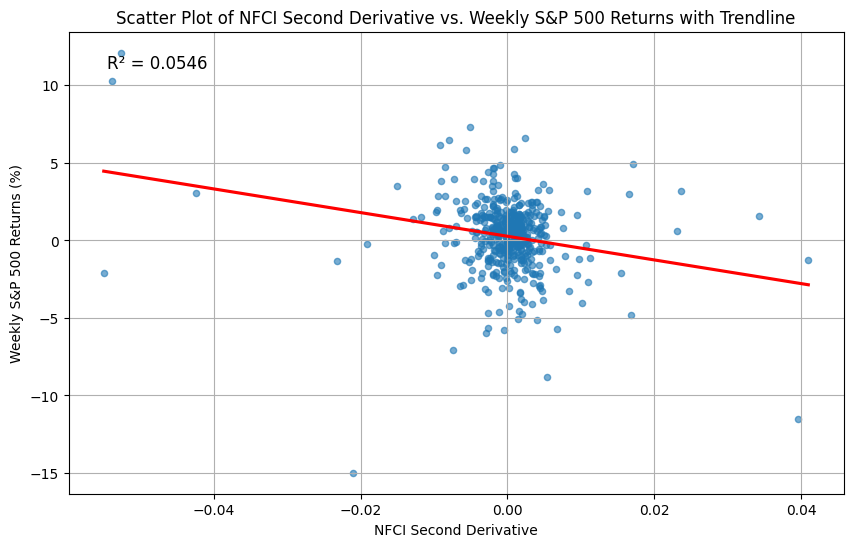

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

# Drop rows with missing values in SP500_Returns and NFCI_Second_Derivative
merged_df_cleaned_second_derivative = merged_df.dropna(subset=['SP500_Returns', 'NFCI_Second_Derivative'])

# Calculate the linear regression
slope_second_deriv, intercept_second_deriv, r_value_second_deriv, p_value_second_deriv, std_err_second_deriv = linregress(merged_df_cleaned_second_derivative['NFCI_Second_Derivative'], merged_df_cleaned_second_derivative['SP500_Returns'])
r_squared_second_deriv = r_value_second_deriv**2

plt.figure(figsize=(10, 6))
sns.regplot(data=merged_df_cleaned_second_derivative, x='NFCI_Second_Derivative', y='SP500_Returns', scatter_kws={'s': 20, 'alpha': 0.6}, line_kws={'color': 'red'}, ci=None)

plt.title('Scatter Plot of NFCI Second Derivative vs. Weekly S&P 500 Returns with Trendline')
plt.xlabel('NFCI Second Derivative')
plt.ylabel('Weekly S&P 500 Returns (%)')

# Add R-squared value to the plot
plt.text(0.05, 0.95, f'R² = {r_squared_second_deriv:.4f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')

plt.grid(True)
plt.show()

#### Interpretation of the Scatter Plot: NFCI Second Derivative vs. Weekly S&P 500 Returns

The scatter plot shows the relationship between the second derivative of the NFCI (the rate of change of the week-over-week change in the NFCI) and the weekly percentage returns of the S&P 500. Each point on the plot represents a specific week.

The trendline appears to be downward sloping. A positive NFCI Second Derivative means that financial conditions are tightening at an accelerating rate, while a negative value means they are loosening at an accelerating rate. The downward slope suggests that when financial conditions are tightening at an accelerating pace, S&P 500 returns tend to be lower, and when they are loosening at an accelerating pace, S&P 500 returns tend to be higher.

The points are quite scattered around the trendline, indicating that the linear relationship between the NFCI Second Derivative and S&P 500 returns is not very strong. The R-squared value of approximately 0.0546 indicates that only about 5.46% of the variance in weekly S&P 500 returns can be explained by the linear relationship with the NFCI Second Derivative. This is a weaker relationship compared to the first derivative of the NFCI (R-squared ~ 0.1112), but slightly stronger than the relationship with the NFCI level (R-squared ~ 0.0004).

In summary, the scatter plot and trendline suggest a weak negative linear relationship between the NFCI Second Derivative and Weekly S&P 500 Returns. While the rate of change of financial conditions seems to have some influence on short-term market returns during this period, it is not a dominant factor in explaining the variation in S&P 500 returns.

## **Concluding Remarks**

In this notebook, we explored the relationship between the Chicago Fed National Financial Conditions Index (NFCI) and the weekly percentage returns of the S&P 500 index from 2016 to 2024. We examined the relationship using the NFCI level, its first derivative (week-over-week change), and its second derivative (rate of change of the week-over-week change).


**NFCI Level vs. S&P 500 Returns:**

The scatter plot and R-squared value (approximately 0.0004) indicated a very weak linear relationship between the NFCI level and weekly S&P 500 returns during this period. While intuition might suggest a negative correlation (looser conditions coinciding with higher returns), the data did not strongly support a simple linear relationship at the level of the index.

**NFCI First Derivative vs. S&P 500 Returns:**
Analyzing the week-over-week change in the NFCI revealed a stronger linear relationship with weekly S&P 500 returns. The scatter plot showed a downward sloping trendline, and the R-squared value (approximately 0.1112) indicated that about 11.12% of the variance in S&P 500 returns could be explained by the linear relationship with the NFCI Derivative. This suggests that the speed and direction of changes in financial conditions had a more discernible linear association with short-term market movements than the absolute level of the index. Specifically, rapid tightening of financial conditions tended to coincide with lower S&P 500 returns, and rapid loosening with higher returns.

**NFCI Second Derivative vs. S&P 500 Returns:**

The relationship between the NFCI Second Derivative and weekly S&P 500 returns was weaker than with the first derivative, but slightly stronger than with the NFCI level. The R-squared value (approximately 0.0546) indicated that about 5.46% of the variance in S&P 500 returns could be explained by the linear relationship with the NFCI Second Derivative. This suggests that while the acceleration or deceleration of financial conditions had some influence, it was not as strong a linear predictor of weekly returns as the direct change in the NFCI.

**Overall Conclusion:**

Based on this analysis from 2016 to 2024, the *change* in financial conditions, as measured by the first derivative of the NFCI, appears to have a more relevant linear relationship with weekly S&P 500 returns than the absolute level or the second derivative of the NFCI. However, even the first derivative only explains a relatively small portion of the variance in weekly S&P 500 returns, indicating that many other factors significantly influence short-term market movements. This analysis highlights the complexity of the relationship between financial conditions and equity markets, suggesting that while the NFCI and its changes can provide some insights, they are not sole determinants of market performance.

In [19]:
import pandas as pd

# R-squared values from previous calculations
r_squared_nfci = r_squared
r_squared_nfci_deriv = r_squared_deriv
r_squared_nfci_second_deriv = r_squared_second_deriv

# Create a dictionary to hold the R-squared values
r_squared_summary = {
    'Variable': ['NFCI Level', 'NFCI First Derivative', 'NFCI Second Derivative'],
    'R-squared with Weekly S&P 500 Returns': [r_squared_nfci, r_squared_nfci_deriv, r_squared_second_deriv]
}

# Create a pandas DataFrame from the dictionary
r_squared_df = pd.DataFrame(r_squared_summary)

# Display the DataFrame
print("Summary of R-squared Values:")
display(r_squared_df)

**Summary of R-squared Values**:


,Variable,R-squared with Weekly S&P 500 Returns
0,NFCI Level,0.000367
1,NFCI First Derivative,0.111217
2,NFCI Second Derivative,0.054583


## **Appendix**

**Time Series Visualization:**

The time series plots below provides a visual context for how the NFCI, its derivatives, and S&P 500 returns evolved over time. While visual inspection can offer insights into coinciding movements during specific periods (e.g., potential market reactions to sharp changes in financial conditions), the scatter plots and R-squared values from the main analysis provided a quantitative measure of the overall linear relationships across the entire period. This appendix is only meant for the sake of general interest.

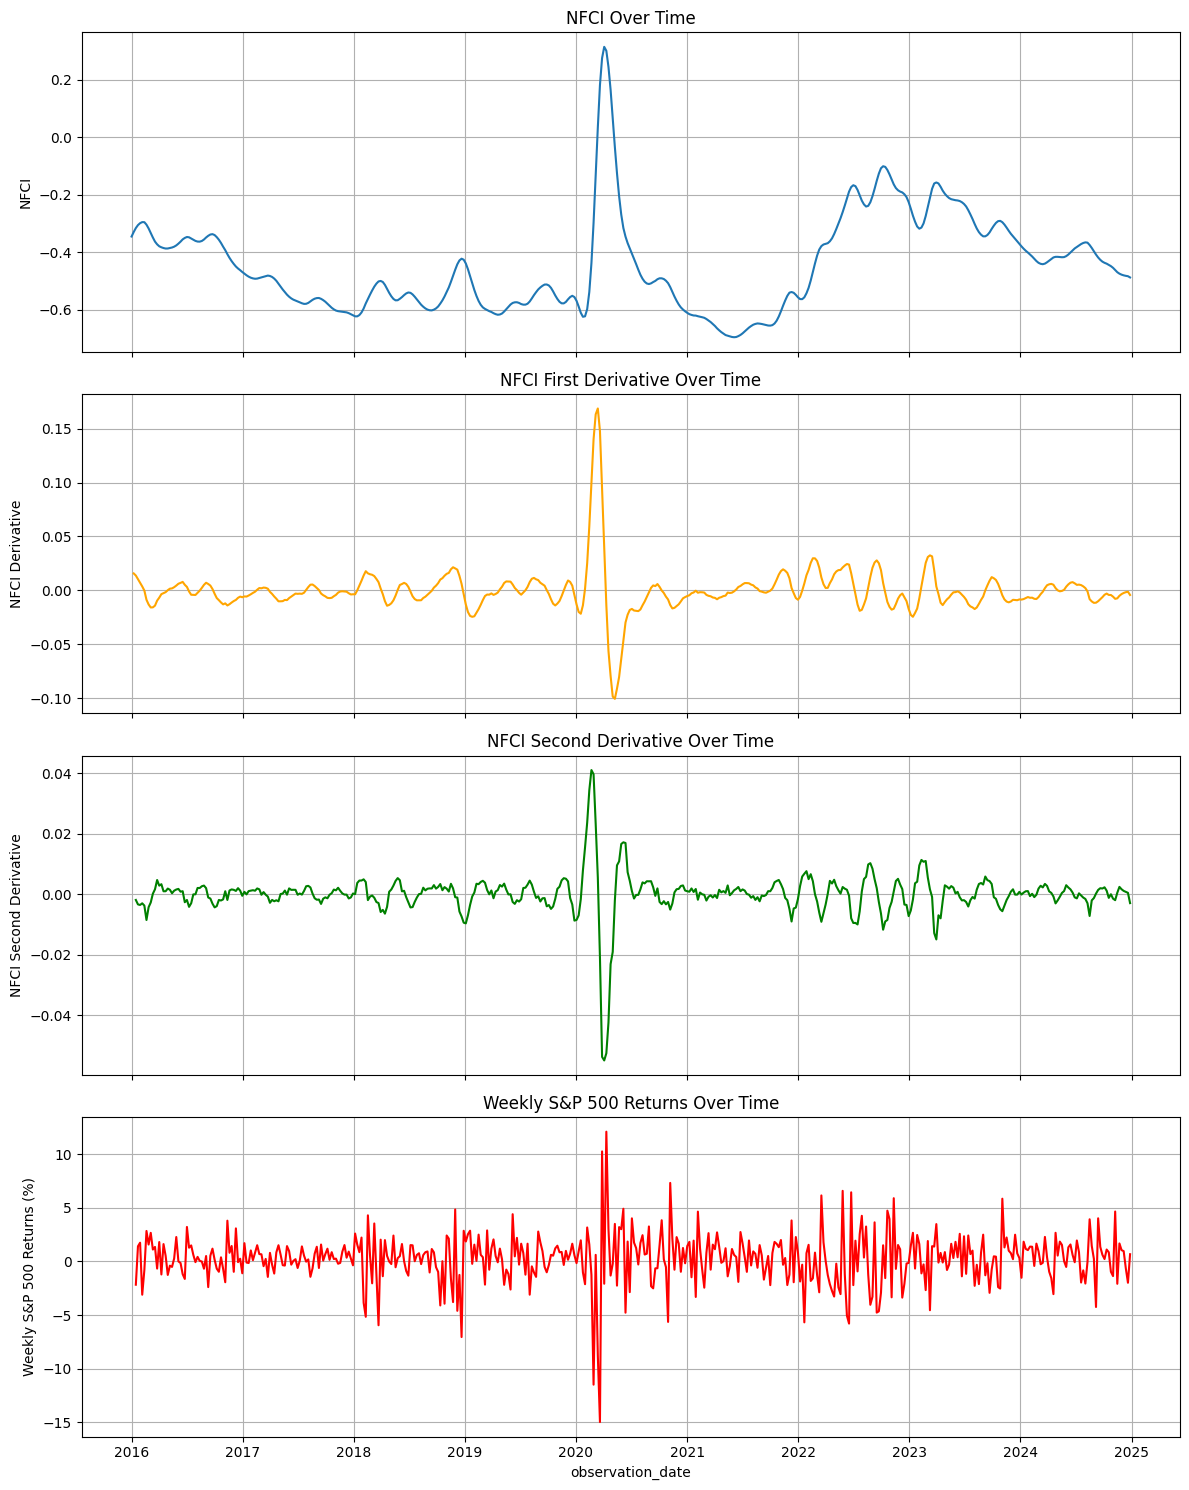

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 1, figsize=(12, 15), sharex=True)

# Plot NFCI
axes[0].plot(merged_df['NFCI'])
axes[0].set_title('NFCI Over Time')
axes[0].set_ylabel('NFCI')
axes[0].grid(True)

# Plot NFCI Derivative
axes[1].plot(merged_df['NFCI_Derivative'], color='orange')
axes[1].set_title('NFCI First Derivative Over Time')
axes[1].set_ylabel('NFCI Derivative')
axes[1].grid(True)

# Plot NFCI Second Derivative
axes[2].plot(merged_df['NFCI_Second_Derivative'], color='green')
axes[2].set_title('NFCI Second Derivative Over Time')
axes[2].set_ylabel('NFCI Second Derivative')
axes[2].grid(True)

# Plot SP500 Returns
axes[3].plot(merged_df['SP500_Returns'], color='red')
axes[3].set_title('Weekly S&P 500 Returns Over Time')
axes[3].set_ylabel('Weekly S&P 500 Returns (%)')
axes[3].set_xlabel('observation_date')
axes[3].grid(True)

plt.tight_layout()
plt.show()